In [2]:
# Analyze new long-format claims
import pandas as pd
from pathlib import Path

# Input file
claims_path = Path("../claims_raw.csv")

# Helper to load if exists
def load_csv(path: Path) -> pd.DataFrame | None:
    if path.exists():
        try:
            return pd.read_csv(path)
        except Exception as e:
            print(f"Failed to read {path}: {e}")
    else:
        print(f"Warning: {path} not found")
    return None

claims_df = load_csv(claims_path)

# Summary: claims long format
if claims_df is not None:
    total = len(claims_df)
    non_empty = int(claims_df['claim'].fillna('').ne('').sum()) if 'claim' in claims_df.columns else 0
    unique_cases = claims_df['name'].nunique() if 'name' in claims_df.columns else None
    print(f"Claims: rows={total}, non_empty_claims={non_empty}, unique_cases={unique_cases}")

    # Show examples: first 5 claims for Supreme Court cases
    def is_supreme_case(row):
        court = str(row.get('court', '')).lower()
        name = str(row.get('name', '')).lower()
        docket = str(row.get('docket', '')).lower()
        return ('supreme' in court) or ('supreme court' in name) or ('scotus' in court) or ('supreme' in docket)

    # If claims csv lacks court, we can’t filter by court; fallback to first 5
    subset = claims_df
    if {'court','name','docket'}.issubset(set(claims_df.columns)):
        subset = claims_df[claims_df.apply(is_supreme_case, axis=1)]
    sample = subset.head(5)
    print(f"\nFirst 5 claims (Supreme Court filtered when possible)")
    display(sample.fillna(''))

Claims: rows=10471, non_empty_claims=10471, unique_cases=3226

First 5 claims (Supreme Court filtered when possible)


,name,docket,claim
0,Roe v. Wade,70-18,The Constitution protects a person's right to ...
1,Roe v. Wade,70-18,States cannot restrict abortion during the fir...
2,Roe v. Wade,70-18,"During the second three months of pregnancy, s..."
3,Roe v. Wade,70-18,"After the fetus can survive outside the womb, ..."
4,Stanley v. Illinois,70-5014,States cannot take children from unwed fathers...


In [3]:
# Check for exactly identical claims
if claims_df is not None and 'claim' in claims_df.columns:
    # Check for duplicates in the 'claim' column
    duplicates = claims_df[claims_df.duplicated(subset=['claim'], keep=False)]
    num_duplicates = len(duplicates)
    unique_duplicates = duplicates['claim'].nunique()
    
    print(f"Found {num_duplicates} rows with identical claims (across {unique_duplicates} unique claim strings).")
    
    if num_duplicates > 0:
        print("\n--- List of Identical Claims and their Sources ---")
        # Sort by claim to group them visually
        sorted_dupes = duplicates.sort_values('claim')
        
        # Group by claim and print details
        for claim_text, group in sorted_dupes.groupby('claim'):
            print(f"\n[Duplicate Claim]: \"{claim_text}\"")
            print(f"Found in {len(group)} entries:")
            # Show name and docket if available
            cols = [c for c in ['name', 'docket'] if c in group.columns]
            if cols:
                for _, row in group.iterrows():
                    source_info = ", ".join([f"{c}: {row[c]}" for c in cols])
                    print(f"  - {source_info}")
            else:
                # Fallback if metadata columns missing
                print(group.to_string(index=False))
else:
    print("Claims dataframe not loaded or missing 'claim' column.")

Found 16 rows with identical claims (across 7 unique claim strings).

--- List of Identical Claims and their Sources ---

[Duplicate Claim]: "A person cannot claim entrapment if they were already willing to commit the crime before law enforcement got involved."
Found in 2 entries:
  - name: Hampton v. United States, docket: 74-5822
  - name: Osborn v. United States, docket: 29

[Duplicate Claim]: "Employers cannot fire someone for being transgender."
Found in 2 entries:
  - name: R.G. & G.R. Harris Funeral Homes Inc. v. Equal Employment Opportunity Commission, docket: 18-107
  - name: R.G. & G.R. Harris Funeral Homes Inc. v. Equal Employment Opportunity Commission, docket: 18-107

[Duplicate Claim]: "Prosecutors cannot remove potential jurors from a jury because of their race."
Found in 4 entries:
  - name: Powers v. Ohio, docket: 89-5011
  - name: Miller-El v. Dretke, docket: 03-9659
  - name: Snyder v. Louisiana, docket: 06-10119
  - name: Flowers v. Mississippi, docket: 17-9572

[Du

In [4]:
# Drop duplicate claims and save
if claims_df is not None and 'claim' in claims_df.columns:
    initial_count = len(claims_df)
    # Drop duplicates, keeping the first occurrence
    claims_df_deduped = claims_df.drop_duplicates(subset=['claim'], keep='first')
    final_count = len(claims_df_deduped)
    dropped_count = initial_count - final_count
    
    print(f"Initial rows: {initial_count}")
    print(f"Rows after deduplication: {final_count}")
    print(f"Dropped {dropped_count} duplicate rows.")
    
    # Update the dataset
    try:
        claims_df_deduped.to_csv(claims_path, index=False)
        print(f"Successfully saved deduplicated dataset to {claims_path}")
        # Update the variable in memory
        claims_df = claims_df_deduped
    except Exception as e:
        print(f"Error saving file: {e}")
else:
    print("Claims dataframe not loaded or missing 'claim' column.")

Initial rows: 10480
Rows after deduplication: 10471
Dropped 9 duplicate rows.
Successfully saved deduplicated dataset to ../claims_raw.csv


--- Standard Factuality Results ---
Total rows: 10471

Counts:
judgement
consistent      8987
inconsistent    1483
Error              1
Name: count, dtype: int64

Percentages:
judgement
consistent      85.83%
inconsistent    14.16%
Error            0.01%
Name: proportion, dtype: object


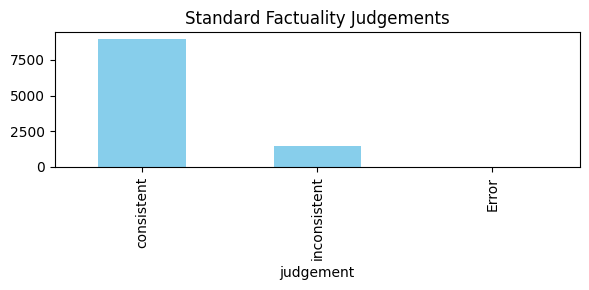

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Define path
std_results_path = "../results/factuality_results.csv"

if os.path.exists(std_results_path):
    df_std = pd.read_csv(std_results_path)
    print(f"--- Standard Factuality Results ---")
    print(f"Total rows: {len(df_std)}")
    
    if 'judgement' in df_std.columns:
        # Clean up judgement column if needed (sometimes whitespace or case)
        df_std['judgement'] = df_std['judgement'].astype(str).str.strip()
        
        counts = df_std['judgement'].value_counts()
        print("\nCounts:")
        print(counts)
        
        print("\nPercentages:")
        print(df_std['judgement'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')
        
        # Simple bar plot
        plt.figure(figsize=(6, 3))
        counts.plot(kind='bar', color='skyblue')
        plt.title('Standard Factuality Judgements')
        plt.tight_layout()
        plt.show()
    else:
        print("Column 'judgement' missing.")
else:
    print(f"File not found: {std_results_path}")

--- Naive Factuality Results ---
Total rows: 10471

Counts:
judgement
consistent      5964
Error           4016
inconsistent     491
Name: count, dtype: int64

Percentages:
judgement
consistent      56.96%
Error           38.35%
inconsistent     4.69%
Name: proportion, dtype: object


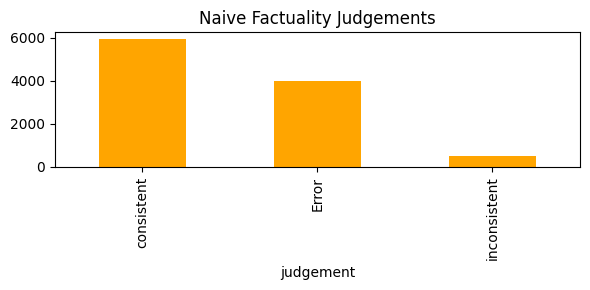

In [4]:
# Define path
naive_results_path = "../results/factuality_naive_results.csv"

if os.path.exists(naive_results_path):
    df_naive = pd.read_csv(naive_results_path)
    print(f"--- Naive Factuality Results ---")
    print(f"Total rows: {len(df_naive)}")
    
    if 'judgement' in df_naive.columns:
        # Clean up
        df_naive['judgement'] = df_naive['judgement'].astype(str).str.strip()
        
        counts = df_naive['judgement'].value_counts()
        print("\nCounts:")
        print(counts)
        
        print("\nPercentages:")
        print(df_naive['judgement'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')
        
        # Simple bar plot
        plt.figure(figsize=(6, 3))
        counts.plot(kind='bar', color='orange')
        plt.title('Naive Factuality Judgements')
        plt.tight_layout()
        plt.show()
    else:
        print("Column 'judgement' missing.")
else:
    print(f"File not found: {naive_results_path}")

In [5]:
# Filter claims based on factuality results
from pathlib import Path

results_path = Path("../results/factuality_results.csv")
output_path = Path("../factual_claims.csv")

if results_path.exists():
    df_results = pd.read_csv(results_path)
    print(f"Loaded {len(df_results)} rows from {results_path}")
    
    if 'judgement' in df_results.columns:
        # Normalize judgement column
        df_results['judgement_clean'] = df_results['judgement'].astype(str).str.lower().str.strip()
        
        # Identify values to drop
        print("Unique judgements found:", df_results['judgement_clean'].unique())
        
        # Define drop criteria: "inconsistent" or "errored out"
        # We use regex to catch variations like "inconsistent" or "error"
        mask_drop = df_results['judgement_clean'].str.contains('inconsistent|error', case=False, regex=True)
        
        df_factual = df_results[~mask_drop].copy()
        
        # Drop the helper column
        df_factual = df_factual.drop(columns=['judgement_clean'])
        
        print(f"Filtered down to {len(df_factual)} rows (dropped {mask_drop.sum()})")
        
        # Save
        df_factual.to_csv(output_path, index=False)
        print(f"Saved factual claims to {output_path}")
        
        # Display sample
        display(df_factual.head())
    else:
        print("Error: 'judgement' column not found in results.")
else:
    print(f"Error: Results file not found at {results_path}")

Loaded 10471 rows from ../results/factuality_results.csv
Unique judgements found: ['consistent' 'inconsistent' 'error']
Filtered down to 8987 rows (dropped 1484)
Saved factual claims to ../factual_claims.csv


,case_name,claim,judgement,explanation,raw_output
0,Roe v. Wade,The Constitution protects a person's right to ...,consistent,The case evidence explicitly states that the C...,"```json\n{\n ""explanation"": ""The case evide..."
1,Roe v. Wade,States cannot restrict abortion during the fir...,consistent,"The case evidence explicitly states that ""In t...","```json\n{\n ""explanation"": ""The case evide..."
2,Roe v. Wade,"During the second three months of pregnancy, s...",consistent,The case evidence states that in the second tr...,"```json\n{\n ""explanation"": ""The case evide..."
3,Roe v. Wade,"After the fetus can survive outside the womb, ...",consistent,The case evidence states that in the third tri...,"```json\n{\n ""explanation"": ""The case evide..."
4,Stanley v. Illinois,States cannot take children from unwed fathers...,consistent,The case evidence states that the Supreme Cour...,"```json\n{\n ""explanation"": ""The case evide..."


In [2]:
# Analyze Contradicted and Overlapping Claims relative to Total Claims (filtered factual_claims.csv)
import pandas as pd
from pathlib import Path

# 1. Load Total Claims from filtered dataset
claims_path = Path("../claims_raw.csv")
if claims_path.exists():
    df_claims = pd.read_csv(claims_path)
    if 'claim' in df_claims.columns:
        claims_norm = df_claims['claim'].astype(str).str.lower().str.strip()
        claims_set = set(claims_norm)
        total_claims = len(df_claims)
        print(f"Total Claims in filtered dataset: {total_claims}")
    else:
        print("Error: 'claim' column missing in factual_claims.csv")
        claims_set = set()
        total_claims = 0
else:
    print("Error: factual_claims.csv not found")
    claims_set = set()
    total_claims = 0

if total_claims > 0 and len(claims_set) > 0:
    # 2. Contradicted Claims
    contradicted_path = Path("../results/contradicted_claims.csv")
    if contradicted_path.exists():
        df_contra = pd.read_csv(contradicted_path)

        if 'contradiction' in df_contra.columns:
            # Normalize label
            df_contra['contradiction'] = df_contra['contradiction'].astype(str).str.lower().str.strip()

            # Identify claim columns in the pairs file
            claim_cols = [c for c in df_contra.columns if 'claim' in c.lower()]
            if len(claim_cols) >= 2:
                c1, c2 = claim_cols[:2]
                df_contra['_c1'] = df_contra[c1].astype(str).str.lower().str.strip()
                df_contra['_c2'] = df_contra[c2].astype(str).str.lower().str.strip()

                checked_pairs = df_contra[df_contra['contradiction'] == 'contradiction']
                eligible_pairs = checked_pairs[checked_pairs['_c1'].isin(claims_set) & checked_pairs['_c2'].isin(claims_set)]
                num_contra_pairs = len(eligible_pairs)

                print(f"\n--- Contradicted Claims ---")
                print(f"Total pairs checked: {len(df_contra)}")
                print(f"Contradictory Pairs Found (both claims present in factual_claims.csv): {num_contra_pairs}")
                print(f"Percentage of total claims (assuming 1 deletion per pair): {(num_contra_pairs / total_claims) * 100:.2f}%")
            else:
                print("Could not find at least two claim columns in contradicted_claims.csv.")
                print(f"Columns seen: {list(df_contra.columns)}")
        else:
            print("Column 'contradiction' missing in contradicted_claims.csv")
    else:
        print(f"File not found: {contradicted_path}")

    # 3. Overlapping Claims
    overlapping_path = Path("../results/overlapping_claims.csv")
    if overlapping_path.exists():
        df_overlap = pd.read_csv(overlapping_path)
        if 'decision' in df_overlap.columns:
            # Normalize label
            df_overlap['decision'] = df_overlap['decision'].astype(str).str.lower().str.strip()

            # Identify claim columns
            claim_cols = [c for c in df_overlap.columns if 'claim' in c.lower()]
            if len(claim_cols) >= 2:
                c1, c2 = claim_cols[:2]
                df_overlap['_c1'] = df_overlap[c1].astype(str).str.lower().str.strip()
                df_overlap['_c2'] = df_overlap[c2].astype(str).str.lower().str.strip()

                checked_pairs = df_overlap[df_overlap['decision'] == 'redundant']
                eligible_pairs = checked_pairs[checked_pairs['_c1'].isin(claims_set) & checked_pairs['_c2'].isin(claims_set)]
                num_redundant_pairs = len(eligible_pairs)

                print(f"\n--- Overlapping Claims ---")
                print(f"Total pairs checked: {len(df_overlap)}")
                print(f"Redundant Pairs Found (both claims present in factual_claims.csv): {num_redundant_pairs}")
                print(f"Percentage of total claims (1 deleted per pair): {(num_redundant_pairs / total_claims) * 100:.2f}%")
            else:
                print("Could not find at least two claim columns in overlapping_claims.csv.")
                print(f"Columns seen: {list(df_overlap.columns)}")
        else:
            print("Column 'decision' missing in overlapping_claims.csv")
    else:
        print(f"File not found: {overlapping_path}")

Total Claims in filtered dataset: 10471

--- Contradicted Claims ---
Total pairs checked: 270
Contradictory Pairs Found (both claims present in factual_claims.csv): 270
Percentage of total claims (assuming 1 deletion per pair): 2.58%

--- Overlapping Claims ---
Total pairs checked: 1858
Redundant Pairs Found (both claims present in factual_claims.csv): 1858
Percentage of total claims (1 deleted per pair): 17.74%


In [2]:
# Analyze Contradicted and Overlapping Claims relative to Total Claims (filtered factual_claims.csv)
import pandas as pd
from pathlib import Path

# 1. Load Total Claims from filtered dataset
claims_path = Path("../factual_claims.csv")
if claims_path.exists():
    df_claims = pd.read_csv(claims_path)
    if 'claim' in df_claims.columns:
        claims_norm = df_claims['claim'].astype(str).str.lower().str.strip()
        claims_set = set(claims_norm)
        total_claims = len(df_claims)
        print(f"Total Claims in filtered dataset: {total_claims}")
    else:
        print("Error: 'claim' column missing in factual_claims.csv")
        claims_set = set()
        total_claims = 0
else:
    print("Error: factual_claims.csv not found")
    claims_set = set()
    total_claims = 0

if total_claims > 0 and len(claims_set) > 0:
    # 2. Contradicted Claims
    contradicted_path = Path("../results/contradicted_claims.csv")
    if contradicted_path.exists():
        df_contra = pd.read_csv(contradicted_path)

        if 'contradiction' in df_contra.columns:
            # Normalize label
            df_contra['contradiction'] = df_contra['contradiction'].astype(str).str.lower().str.strip()

            # Identify claim columns in the pairs file
            claim_cols = [c for c in df_contra.columns if 'claim' in c.lower()]
            if len(claim_cols) >= 2:
                c1, c2 = claim_cols[:2]
                df_contra['_c1'] = df_contra[c1].astype(str).str.lower().str.strip()
                df_contra['_c2'] = df_contra[c2].astype(str).str.lower().str.strip()

                checked_pairs = df_contra[df_contra['contradiction'] == 'contradiction']
                eligible_pairs = checked_pairs[checked_pairs['_c1'].isin(claims_set) & checked_pairs['_c2'].isin(claims_set)]
                num_contra_pairs = len(eligible_pairs)

                print(f"\n--- Contradicted Claims ---")
                print(f"Total pairs checked: {len(df_contra)}")
                print(f"Contradictory Pairs Found (both claims present in factual_claims.csv): {num_contra_pairs}")
                print(f"Percentage of total claims (assuming 1 deletion per pair): {(num_contra_pairs / total_claims) * 100:.2f}%")
            else:
                print("Could not find at least two claim columns in contradicted_claims.csv.")
                print(f"Columns seen: {list(df_contra.columns)}")
        else:
            print("Column 'contradiction' missing in contradicted_claims.csv")
    else:
        print(f"File not found: {contradicted_path}")

    # 3. Overlapping Claims
    overlapping_path = Path("../results/overlapping_claims.csv")
    if overlapping_path.exists():
        df_overlap = pd.read_csv(overlapping_path)
        if 'decision' in df_overlap.columns:
            # Normalize label
            df_overlap['decision'] = df_overlap['decision'].astype(str).str.lower().str.strip()

            # Identify claim columns
            claim_cols = [c for c in df_overlap.columns if 'claim' in c.lower()]
            if len(claim_cols) >= 2:
                c1, c2 = claim_cols[:2]
                df_overlap['_c1'] = df_overlap[c1].astype(str).str.lower().str.strip()
                df_overlap['_c2'] = df_overlap[c2].astype(str).str.lower().str.strip()

                checked_pairs = df_overlap[df_overlap['decision'] == 'redundant']
                eligible_pairs = checked_pairs[checked_pairs['_c1'].isin(claims_set) & checked_pairs['_c2'].isin(claims_set)]
                num_redundant_pairs = len(eligible_pairs)

                print(f"\n--- Overlapping Claims ---")
                print(f"Total pairs checked: {len(df_overlap)}")
                print(f"Redundant Pairs Found (both claims present in factual_claims.csv): {num_redundant_pairs}")
                print(f"Percentage of total claims (1 deleted per pair): {(num_redundant_pairs / total_claims) * 100:.2f}%")
            else:
                print("Could not find at least two claim columns in overlapping_claims.csv.")
                print(f"Columns seen: {list(df_overlap.columns)}")
        else:
            print("Column 'decision' missing in overlapping_claims.csv")
    else:
        print(f"File not found: {overlapping_path}")

Total Claims in filtered dataset: 8987

--- Contradicted Claims ---
Total pairs checked: 270
Contradictory Pairs Found (both claims present in factual_claims.csv): 90
Percentage of total claims (assuming 1 deletion per pair): 1.00%

--- Overlapping Claims ---
Total pairs checked: 1858
Redundant Pairs Found (both claims present in factual_claims.csv): 1568
Percentage of total claims (1 deleted per pair): 17.45%


#### Contradictions
##### Statistics
- **One claim removed:** 81  
- **Both claims removed:** 6  
- **Both removed and replaced:** 3  

---

- **Removing:** 90 claims  
- **Adding:** 3 new claims  
- **Final claim count:** 8900


#### Overlaps

##### Statistics
- **Claim 1 kept:** 926  
- **Claim 2 kept:** 619  

---

- **Removing:** 1317 claims  
- **Final claim count:** 7583